# Runtime: < 30mins

**Setting** the file directory to the data folder. All files will be referenced to this working directory.

**Run from repo root** (`cwd = QuantumVRP/`).

Folder structure per city:
```
data_real/{city_lower}/
├── raw/pickup/          # raw OSM downloads
├── raw/dropoff/
├── Pickup Point Data/   # processed (consumed by real_loader.py)
├── Drop Point Data/     # processed (consumed by real_loader.py)
├── census/              # census processing artifacts
├── images/              # visualizations
└── stats/               # metrics
```

In [12]:
import pandas as pd
import json
import geojson
import overpass
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

In [13]:
idx = -1

my_states = ["New Mexico", "Massachusetts", "Ohio", "Texas", "Florida", "Washington", "Illinois", "New Mexico"]
state_name = my_states[idx]


my_cities = ["Albuquerque", "Boston", "Cleveland", "Dallas", "Miami", "Seattle", "Chicago", "Santa Fe"]
city_name = my_cities[idx]

re_gen = True

In [14]:
# Default size of images
size = (16,16)

# Function to check for img directory and save image
def save_image(plot, img_name: str):
  os.makedirs(data_dir + "/images", exist_ok=True)
  plot.savefig(f'{data_dir}/images/{img_name}.png')

In [15]:
# Ensure working directory is repo root (parent of city_data_generation/)
if os.path.basename(os.getcwd()) == "city_data_generation":
    os.chdir("..")

data_dir = os.path.join("data_real", city_name.lower().replace(" ", "_"))
os.makedirs(data_dir, exist_ok=True)

# See directory content
print("cwd:", os.getcwd())
print("data_dir:", os.path.abspath(data_dir))
print("Files:", os.listdir(data_dir))

cwd: /Users/colinkula/Desktop/SDP/QuantumVRP
data_dir: /Users/colinkula/Desktop/SDP/QuantumVRP/data_real/santa_fe
Files: ['Pickup Point Data', 'Drop Point Data', 'census', 'raw']


# Getting Consumer and Producer data


Using OSM, we can query locations that are suited for our study. We need those locations which can either provide food or act as a potential drop location for a customer. Thse locations can be queried using Overpass API that uses the OSM data. While it is possible to use the OSMPythonTools for queries the data uses python scripts, it is easier to query and visualise data from Overpass Turbo and directly download the data from the site in the `.geojson` format. The latter was used for this notebook but now they are directly gotten using Overpass API. These data files are stored in `Original Data` folder.

In [16]:

def buildQuery(stateName, cityName, category, tag, is_dc=False):
  if is_dc:
    return f"""
          [out:json][timeout:3600];
          area[name=\"United States\"][\"admin_level\"=\"2\"]->.country;
          area[name=\"{stateName}\"][\"admin_level\"=\"4\"]->.state;
          (
            way[\"{category}\"=\"{tag}\"](area.country)(area.state);
            node[\"{category}\"=\"{tag}\"](area.country)(area.state);
          );
          out body;
          >;
          out skel qt;
          """
  else:
    return f"""
          [out:json][timeout:3600];
          area[name=\"United States\"][\"admin_level\"=\"2\"]->.country;
          area[name=\"{stateName}\"][\"admin_level\"=\"4\"]->.state;
          area[name=\"{cityName}\"]->.city;
          (
            way[\"{category}\"=\"{tag}\"](area.country)(area.state)(area.city);
            node[\"{category}\"=\"{tag}\"](area.country)(area.state)(area.city);
          );
          out body;
          >;
          out skel qt;
          """

# Test print to make sure it works
print(buildQuery(state_name, city_name, "building", "dormitory"))


          [out:json][timeout:3600];
          area[name="United States"]["admin_level"="2"]->.country;
          area[name="New Mexico"]["admin_level"="4"]->.state;
          area[name="Santa Fe"]->.city;
          (
            way["building"="dormitory"](area.country)(area.state)(area.city);
            node["building"="dormitory"](area.country)(area.state)(area.city);
          );
          out body;
          >;
          out skel qt;
          


In [17]:
#Converts the raw osm data into a geojson object, this object needs to be in the same form that the original data gathered @
# https://overpass-turbo.eu/ is in. More information about the geojson can be found in the help section of overpass turbo.

def overpass_to_geojson(overpass_data):
  node_dict = {node['id']: node for node in overpass_data['elements'] if node['type'] == 'node'}
  features = []
  for element in overpass_data['elements']:
    if 'tags' in element.keys():
      if element['type'] == 'way':
        coordinates = [[node_dict[node_id]['lon'], node_dict[node_id]['lat']] for node_id in element['nodes']]
        # Ensure the polygon is closed by repeating the first coordinate at the end
        if coordinates[0] != coordinates[-1]:
          coordinates.append(coordinates[0])
        geometry = {'type': 'Polygon', 'coordinates': [coordinates]}
        properties = {'@id': f"way/{element['id']}", **element['tags']}  # Include tags directly within properties
        feature = {'type': 'Feature', 'id': f"way/{element['id']}", 'properties': properties, 'geometry': geometry}  # Include 'id' here
        features.append(feature)
      if element['type'] == 'node':
        coordinates = [[element['lon'], element['lat']]]
        geometry = {'type': 'Point', 'coordinates': [coordinates]}
        properties = {'@id': f"node/{element['id']}", **element['tags']}
        feature = {'type': 'Feature', 'id': f"node/{element['id']}", 'properties': properties, 'geometry': geometry}
        features.append(feature)
  feature_collection = {
    'type': 'FeatureCollection',
    'features': features,
    'generator': 'overpass-turbo',  # Added generator field
    'copyright': 'The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.',  # Added copyright field
    'timestamp': '2024-06-02T00:20:11Z'  # Added timestamp field
  }
  return feature_collection


#Creating the GeoJSON


Geojson provides easy and effecient to handle geo data. It has only one main requirement - every data frame element needs to have an attribute that contains geometry objects. Usually it is named as `geometry` or needs to be specified seperately if the name is different.

In [18]:
def save_data(query, fileName):
  query_sub = query[query.index("("):]
  print("Query: " + query_sub[7:query_sub.index("]")+1])

  # Create an Overpass API object
  api = overpass.API(timeout=3600)

  #This took hours to find out, if build is not set to false by default it tries to add its own "[out:json];" and "out body;" at the begining and end
  result = api.get(query, build=False)
  print("Result done.")


  if(fileName in pickLocations):
    modifier = "raw/pickup"
  else:
    modifier = "raw/dropoff"


  data = overpass_to_geojson(result)
  print("Count:", len(data['features']))


  with open(data_dir + "/" + modifier + "/" + fileName, 'w') as f:
    json.dump(data, f, indent=2)
  print("Dumped.", end="\n------\n")

In [19]:
# NOTE: fileNames must be in the same order as queries below.
# The original had these out of sync starting at index 4, causing files to be
# saved under wrong names and in wrong directories. Fixed 2026-03-18.
fileNames = [
  "restaurant_raw_data.geojson",
  "cafe_raw_data.geojson",
  "apartments_raw_data.geojson",
  "residential_raw_data.geojson",
  "fast_food_raw_data.geojson",
  "food_court_raw_data.geojson",
  "college_raw_data.geojson",
  "university_raw_data.geojson",
  "dormitory_raw_data.geojson",
  "hospital_raw_data.geojson",
  "detached_raw_data.geojson",
  "hotel_raw_data.geojson",
  "house_raw_data.geojson",
  "office_raw_data.geojson",
  "community_centre_raw_data.geojson",
  "bakery_raw_data.geojson",
  "supermarket_raw_data.geojson"
]

pickLocations = ["supermarket_raw_data.geojson","restaurant_raw_data.geojson","cafe_raw_data.geojson","fast_food_raw_data.geojson","food_court_raw_data.geojson","bakery_raw_data.geojson"]
dropLocations = ["apartments_raw_data.geojson","residential_raw_data.geojson","college_raw_data.geojson","university_raw_data.geojson","dormitory_raw_data.geojson","hospital_raw_data.geojson","detached_raw_data.geojson","hotel_raw_data.geojson","house_raw_data.geojson","office_raw_data.geojson","community_centre_raw_data.geojson"]


os.makedirs(data_dir + "/raw/pickup", exist_ok=True)
os.makedirs(data_dir + "/raw/dropoff", exist_ok=True)
os.makedirs(data_dir + "/Pickup Point Data", exist_ok=True)
os.makedirs(data_dir + "/Drop Point Data", exist_ok=True)


consumer_producer_data_exists = True

for fName in pickLocations:
  if (not os.path.isfile(data_dir + "/raw/pickup/"
                                  + fName)):
    consumer_producer_data_exists = False


# updated to work with dropoff locations
for fName in dropLocations:
  if (not os.path.isfile(data_dir + "/raw/dropoff/"
                                  + fName)):
    consumer_producer_data_exists = False


if(consumer_producer_data_exists == False or re_gen):


  queries = [
    buildQuery(state_name, city_name, "amenity", "restaurant"),
    buildQuery(state_name, city_name, "amenity", "cafe"),
    buildQuery(state_name, city_name, "building", "apartments"),
    buildQuery(state_name, city_name, "building", "residential"),
    buildQuery(state_name, city_name, "amenity", "fast_food"),
    buildQuery(state_name, city_name, "amenity", "food_court"),
    buildQuery(state_name, city_name, "building", "college"),
    buildQuery(state_name, city_name, "building", "university"),
    buildQuery(state_name, city_name, "building", "dormitory"),
    buildQuery(state_name, city_name, "building", "hospital"),
    buildQuery(state_name, city_name, "building", "detached"),
    buildQuery(state_name, city_name, "building", "hotel"),
    buildQuery(state_name, city_name, "building", "house"),
    buildQuery(state_name, city_name, "building", "office"),
    buildQuery(state_name, city_name, "amenity", "community_centre"),
    buildQuery(state_name, city_name, "shop", "bakery"),
    buildQuery(state_name, city_name, "shop", "supermarket")
  ]

import time

for i, query in enumerate(queries):
    success = False
    retries = 3
    while not success and retries > 0:
        try:
            save_data(query, fileNames[i])
            time.sleep(5)
            success = True
        except overpass.errors.MultipleRequestsError:
            print("Hit rate limit, retrying in 30 seconds...")
            time.sleep(30)
            retries -= 1
        except overpass.errors.ServerLoadError:
            print("Server overloaded, retrying in 60 seconds...")
            time.sleep(60)
            retries -= 1

Query:        way["amenity"="restaurant"]
Result done.
Count: 203
Dumped.
------
Query:        way["amenity"="cafe"]
Result done.
Count: 74
Dumped.
------
Query:        way["building"="apartments"]
Result done.
Count: 602
Dumped.
------
Query:        way["building"="residential"]
Hit rate limit, retrying in 30 seconds...
Query:        way["building"="residential"]
Result done.
Count: 145
Dumped.
------
Query:        way["amenity"="fast_food"]
Result done.
Count: 89
Dumped.
------
Query:        way["amenity"="food_court"]
Hit rate limit, retrying in 30 seconds...
Query:        way["amenity"="food_court"]
Hit rate limit, retrying in 30 seconds...
Query:        way["amenity"="food_court"]
Result done.
Count: 6
Dumped.
------
Query:        way["building"="college"]
Result done.
Count: 4
Dumped.
------
Query:        way["building"="university"]
Server overloaded, retrying in 60 seconds...
Query:        way["building"="university"]
Server overloaded, retrying in 60 seconds...
Query:        w

Like MySQL, GeoPandas also provides join operations on data frames using the geometry attribute. Doing a left-join on the locations and census tracts assigns every selected location to a census tract.
Also after joining the 2 data frames, uneccessary attributes from the OSM data are dropped. This significantly reduced file size (by almost 10 times in most cases!)
<br>
<br>
*IMPORTANT NOTE*
<br>
Since we are no longer using the old way of having way and node files for each data location the old named files must no longer be in the folder as the drop files will still have the same name overwriting them but the pick files will have different names than the original processed output causing the original Chicago pickup locations to show up unless the original pickup files are removed.

### Adding Tract ID to Consumer/Producer Data

In [20]:
#Edited to allow for generic city use

census_dir = os.path.join("city_data_generation", "census_raw", state_name + ".geojson")
if not os.path.exists(census_dir):
    # Fallback if cwd is already city_data_generation/
    census_dir = os.path.join("census_raw", state_name + ".geojson")
census_df = gpd.read_file(census_dir)

#All attributes of a geojson converted from census.gov shapefiles using ogr2ogr
#keeping GEOID as it represents a unique identifier for each census tract. It is a combination of the census ID which is only unqiue within
#a county, county ID which is only unique within a state, and the state ID. This makes a fully unique idetifier that is 11 digits long.
census_df = census_df.drop('STATEFP', axis=1)
census_df = census_df.drop('COUNTYFP', axis=1)
census_df = census_df.drop('TRACTCE', axis=1)
census_df = census_df.drop('AFFGEOID', axis=1)
# census_df = census_df.drop('GEOID', axis=1)
census_df = census_df.drop('NAME', axis=1)
census_df = census_df.drop('LSAD', axis=1)
census_df = census_df.drop('ALAND', axis=1)
census_df = census_df.drop('AWATER', axis=1)


os.makedirs(data_dir + "/census/", exist_ok=True)

In [21]:
census_df['GEOID'] = census_df['GEOID'].astype(str)
census_df.to_file(data_dir + "/census/RAW_census_tract_data.geojson", driver="GeoJSON")

In [22]:
census_dir = data_dir + "/census/RAW_census_tract_data.geojson"
census_df = gpd.read_file(census_dir)

# loading directotry of raw pickup locations
pick_data_dir = data_dir + "/raw/pickup/"
pick_files = os.listdir(pick_data_dir)
print(pick_files)
for file_name in pick_files:
  file_dir = pick_data_dir + file_name
  file_df = gpd.read_file(file_dir)


  # edited to make generic crs match
  file_df = file_df.to_crs(census_df.crs)
  #####

  join_left_df = file_df.sjoin(census_df, how="left")
  join_left_df = join_left_df.dropna(subset=['GEOID'])


  for column in join_left_df.columns.tolist():
    if (column not in ["@id", "name", "geometry", "amenity", "building", "shop", "GEOID"]):
      join_left_df = join_left_df.drop(column, axis=1)

  # making file name for storing lat long of all locations
  new_file_dir = data_dir + "/Pickup Point Data/" + file_name
  new_file_dir = new_file_dir[:-16]
  new_file_dir += "location_data.geojson"

  join_left_df.to_file(new_file_dir, driver="GeoJSON")

['cafe_raw_data.geojson', 'food_court_raw_data.geojson', 'bakery_raw_data.geojson', 'restaurant_raw_data.geojson', 'supermarket_raw_data.geojson', 'fast_food_raw_data.geojson']


In [23]:
census_dir = data_dir + "/census/RAW_census_tract_data.geojson"
census_df = gpd.read_file(census_dir)

# loading directotry of raw drop locations
drop_data_dir = data_dir + "/raw/dropoff/"
drop_files = os.listdir(drop_data_dir)
print(drop_files)
for file_name in drop_files:
  file_dir = drop_data_dir + file_name
  file_df = gpd.read_file(file_dir)

  # edited to make generic crs match
  file_df = file_df.to_crs(census_df.crs)
  #####


  join_left_df = file_df.sjoin(census_df, how="left")
  join_left_df = join_left_df.dropna(subset=['GEOID'])


  for column in join_left_df.columns.tolist():
    if (column not in ["@id", "name", "geometry", "amenity", "building", "shop", "GEOID"]):
      join_left_df = join_left_df.drop(column, axis=1)

  # making file name for storing lat long of all locations
  new_file_dir = data_dir + "/Drop Point Data/" + file_name
  new_file_dir = new_file_dir[:-16]
  new_file_dir += "location_data.geojson"

  join_left_df.to_file(new_file_dir, driver="GeoJSON")

['office_raw_data.geojson', 'residential_raw_data.geojson', 'college_raw_data.geojson', 'community_centre_raw_data.geojson', 'hospital_raw_data.geojson', 'detached_raw_data.geojson', 'apartments_raw_data.geojson', 'house_raw_data.geojson', 'dormitory_raw_data.geojson', 'university_raw_data.geojson', 'hotel_raw_data.geojson']


### Find tracts with producers and consumers
These two sections are to get the tracts that have data points within them. This will help to remove all tracts which have no pickup or drop points within them so that they may be discarded to allow for faster data processing.

In [24]:
#Stores all census tract id's that are used
pick_tracts = set()

pick_data_dir = data_dir + "/Pickup Point Data/"
pick_files = os.listdir(pick_data_dir)
print("Files for Pickup Points Data: ",pick_files)

for file_name in pick_files:
  file_dir = pick_data_dir + file_name

  with open(file_dir, 'r') as f:
    data = json.load(f)["features"]

    for element in data:

      properties = element["properties"]
      ID = properties["GEOID"]

      #Used later for tracking which census tracts have points within them to remove tracts without any data points
      pick_tracts.add(ID)

Files for Pickup Points Data:  ['restaurant_location_data.geojson', 'fast_food_location_data.geojson', 'bakery_location_data.geojson', 'supermarket_location_data.geojson', 'cafe_location_data.geojson', 'food_court_location_data.geojson']


In [25]:
drop_tracts = set()

drop_data_dir = data_dir + "/Drop Point Data/"
drop_files = os.listdir(drop_data_dir)
print("Files for Drop Points Data: ",drop_files)

for file_name in drop_files:
  file_dir = drop_data_dir + file_name

  with open(file_dir, 'r') as f:
    data = json.load(f)["features"]

    for element in data:
      properties = element["properties"]
      ID = properties["GEOID"]

      #Used later for tracking which census tracts have points within them to remove tracts without any data points
      drop_tracts.add(ID)

Files for Drop Points Data:  ['dormitory_location_data.geojson', 'detached_location_data.geojson', 'residential_location_data.geojson', 'college_location_data.geojson', 'house_location_data.geojson', 'university_location_data.geojson', 'community_centre_location_data.geojson', 'hotel_location_data.geojson', 'hospital_location_data.geojson', 'office_location_data.geojson', 'apartments_location_data.geojson']


In [26]:
# If you want to skip Convex Hull step, run this code block...
census_dir = data_dir + "/census/RAW_census_tract_data.geojson"
census_df = gpd.read_file(census_dir)
census_df.to_file(data_dir + "/census/census_tract_data.geojson", driver="GeoJSON")

/var/folders/l2/0cks6r0s55j26mlk150352_00000gn/T/ipykernel_14363/4156819270.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  selected_gdf['centroid'] = selected_gdf.geometry.centroid
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/l2/0cks6r0s55j26mlk150352_00000gn/T/ipykernel_14363/4156819270.py:45: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to ma

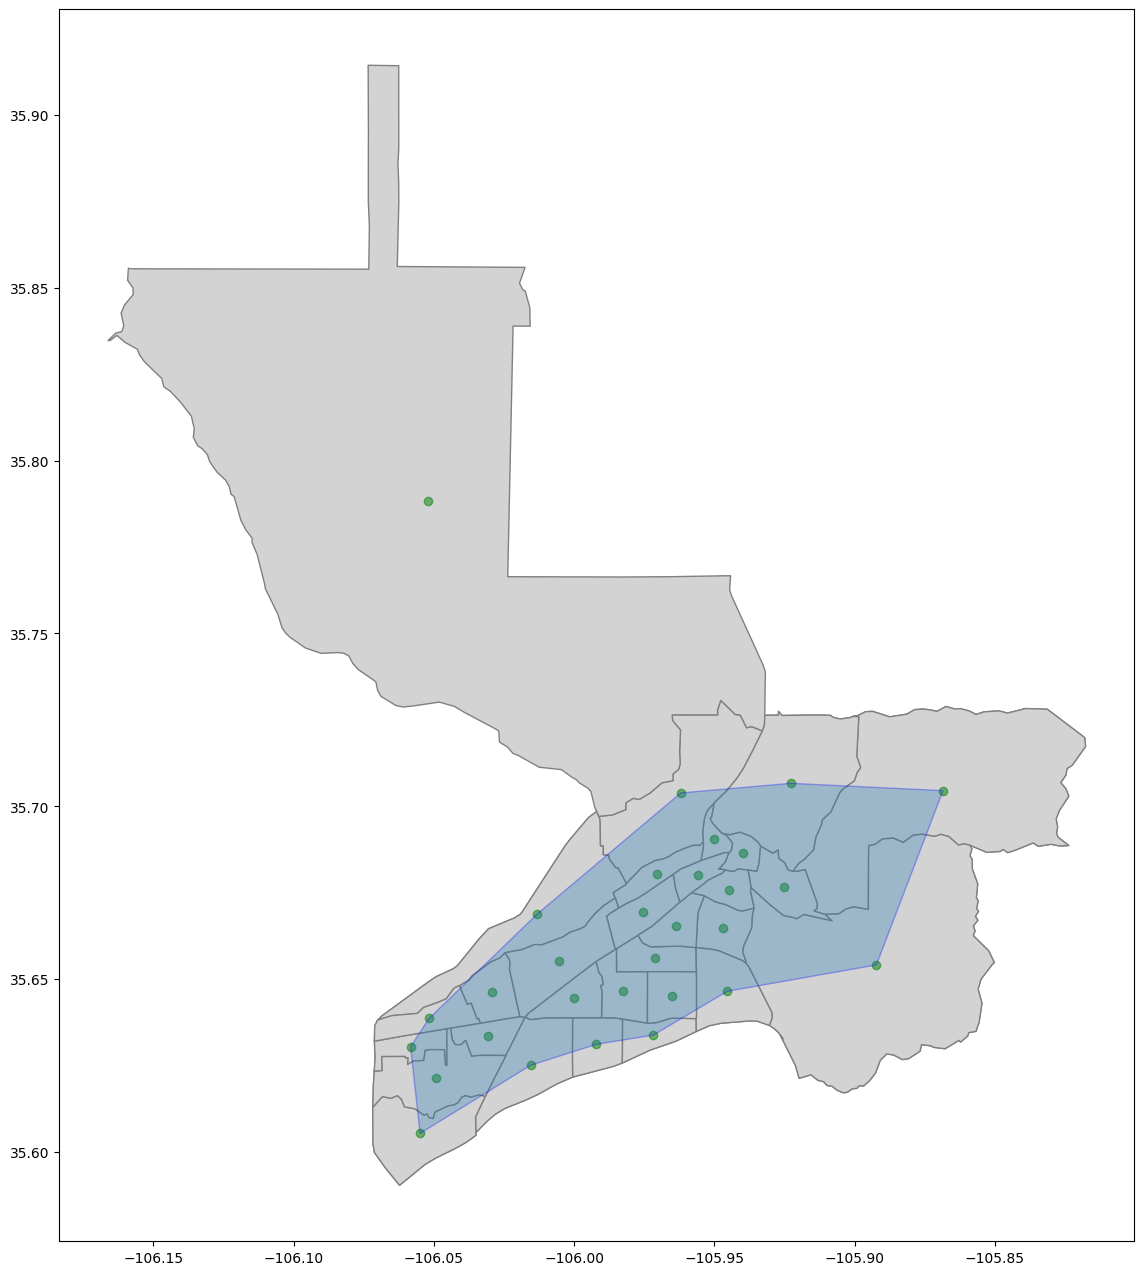

In [27]:
from shapely.geometry import MultiPoint, Polygon, LineString
from scipy.spatial import ConvexHull
import numpy as np

census_dir = data_dir + "/census/RAW_census_tract_data.geojson"
census_df = gpd.read_file(census_dir)

tracts = pick_tracts
for tract in drop_tracts:
  tracts.add(tract)


selected_gdf = census_df[census_df['GEOID'].isin(tracts)]
selected_gdf.to_file(data_dir + "/census/TEST_sel.geojson", driver="GeoJSON")

non_selected_gdf = census_df[~census_df['GEOID'].isin(tracts)]
non_selected_gdf.to_file(data_dir + "/census/TEST_nonsel.geojson", driver="GeoJSON")


# Check and fix invalid geometries
if not selected_gdf.is_valid.all():
    selected_gdf = selected_gdf[selected_gdf.is_valid]
if not non_selected_gdf.is_valid.all():
    non_selected_gdf = non_selected_gdf[non_selected_gdf.is_valid]


# Find the centroid point of each tract
selected_gdf['centroid'] = selected_gdf.geometry.centroid

# Extract the centroid coordinates as a list of tuples
centroid_coords = [(point.x, point.y) for point in selected_gdf['centroid']]

# Calculate the concave hull (alpha shape) with a custom alpha value
alpha_value = 50 # Adjust the alpha value as needed

for alpha in range (1, 20):
    concave_hull = alphashape(centroid_coords, alpha=alpha)
    if (type(concave_hull) != Polygon):
      continue
    alpha_value = alpha



concave_hull = alphashape(centroid_coords, alpha=alpha_value)
surrounded_tracts = gpd.sjoin(census_df, gpd.GeoDataFrame(geometry=[concave_hull]), predicate='intersects')


# Plotting
fig, ax = plt.subplots(figsize=size)

surrounded_tracts.plot(ax=ax, color='red', edgecolor='grey')
selected_gdf.plot(ax=ax, color='lightgrey', edgecolor='grey')
ax.scatter(selected_gdf['centroid'].x, selected_gdf['centroid'].y, color='green', alpha=0.5)
ax.fill(*zip(*concave_hull.exterior.coords), alpha=0.3, edgecolor='blue')
save_image(plt, 'city_removed_tracts')
plt.show()



selected_gdf = pd.concat([selected_gdf, surrounded_tracts])
census_df = census_df[census_df['GEOID'].isin(selected_gdf['GEOID'])]


census_df.to_file(data_dir + "/census/census_tract_data.geojson", driver="GeoJSON")

# Sorting Consumer/Producer Data

In [28]:
census_data = dict()

# loading directotry of sorted by type pickup locations
pick_data_dir = data_dir + "/Pickup Point Data/"
pick_files = os.listdir(pick_data_dir)
print("Files for Pickup Points Data: ",pick_files)

for file_name in pick_files:
  file_dir = pick_data_dir + file_name

  with open(file_dir, 'r') as f:
    data = json.load(f)["features"]

    #print(data)

    for element in data:
      properties = element["properties"]
      tract = properties["GEOID"]
      amenity = None
      building = None
      shop = None



      if "amenity" in properties.keys():
        amenity = properties["amenity"]
      if "building" in properties.keys():
        building = properties["building"]
      if "shop" in properties.keys():
        shop = properties["shop"]

      if (element["geometry"]["type"] == "Polygon"):
        coordinates = element["geometry"]["coordinates"][0]
        latitude = np.mean([point[1] for point in coordinates])
        longitude = np.mean([point[0] for point in coordinates])

      elif (element["geometry"]["type"] == "Point"):
        latitude = element["geometry"]["coordinates"][1]
        longitude = element["geometry"]["coordinates"][0]

      if tract not in census_data.keys():
        census_data[tract] = []

      census_data[tract].append({
            "id" : properties["@id"],
            "amenity" : amenity,
            "building" : building,
            "shop": shop,
            "lat" : latitude,
            "lon" : longitude
        })

Files for Pickup Points Data:  ['restaurant_location_data.geojson', 'fast_food_location_data.geojson', 'bakery_location_data.geojson', 'supermarket_location_data.geojson', 'cafe_location_data.geojson', 'food_court_location_data.geojson']


Repeating the same for drop locations

In [29]:
# loading directotry of sorted by type drop locations
drop_data_dir = data_dir + "/Drop Point Data/"
drop_files = os.listdir(drop_data_dir)
print("Files for Drop Points Data: ",drop_files)

for file_name in drop_files:
  file_dir = drop_data_dir + file_name

  with open(file_dir, 'r') as f:
    data = json.load(f)["features"]

    for element in data:
      properties = element["properties"]
      tract = properties["GEOID"]
      amenity = None
      building = None
      shop = None

      if "amenity" in properties.keys():
        amenity = properties["amenity"]
      if "building" in properties.keys():
        building = properties["building"]
      if "shop" in properties.keys():
        shop = properties["shop"]

      coordinates = element["geometry"]["coordinates"][0]
      latitude = np.mean([point[1] for point in coordinates])
      longitude = np.mean([point[0] for point in coordinates])

      if tract not in census_data.keys():
        census_data[tract] = []

      census_data[tract].append({
            "id" : properties["@id"],
            "amenity" : amenity,
            "building" : building,
            "shop": shop,
            "lat" : latitude,
            "lon" : longitude
        })

Files for Drop Points Data:  ['dormitory_location_data.geojson', 'detached_location_data.geojson', 'residential_location_data.geojson', 'college_location_data.geojson', 'house_location_data.geojson', 'university_location_data.geojson', 'community_centre_location_data.geojson', 'hotel_location_data.geojson', 'hospital_location_data.geojson', 'office_location_data.geojson', 'apartments_location_data.geojson']


This final cell writes the data into a `.json`

In [30]:
json_object = json.dumps(census_data, indent=4)

with open (data_dir + "/census/census_tract_wise_locations.json", 'w') as f:
  f.write(json_object)

# Store Metrics

In [31]:
stats_dir_path = os.path.join(data_dir, "stats")
stats_path = os.path.join(stats_dir_path, "stats.json")
drop_dir = os.path.join(data_dir, "Drop Point Data")
pickup_dir = os.path.join(data_dir, "Pickup Point Data")
census_dir = os.path.join(data_dir, "census")
census_path = os.path.join(census_dir, "census_tract_wise_locations.json")

stats_data = {}
census_data = {}

# Stats dir create
try:
    os.makedirs(stats_dir_path, exist_ok=True)
except Exception as e:
    print(f"Cant make stats dir")

# Stats load
if os.path.exists(stats_path):
    try:
        with open(stats_path, 'r') as f:
            stats_data = json.load(f)
    except Exception as e:
        print("Cant load stats file")

# Census load
if os.path.exists(census_path):
    try:
        with open(census_path, 'r') as f:
            census_data = json.load(f)
    except Exception as e:
        print("Cant load census file")

total_census_tracts = len(census_data)
# print(total_census_tracts)


total_pickup_locations = 0
max_pickup = float('-inf')
min_pickup = float('inf')
for fn in os.listdir(pickup_dir):
    if fn.endswith('.geojson'):
        temp_path = os.path.join(pickup_dir, fn)
        gdf = gpd.read_file(temp_path)
        num_pickup_locs = len(gdf)
        total_pickup_locations += num_pickup_locs
        max_pickup = max(max_pickup, num_pickup_locs)
        min_pickup = min(min_pickup, num_pickup_locs)

total_dropoff_locations = 0
max_drop = float('-inf')
min_drop = float('inf')
for fn in os.listdir(drop_dir):
    if fn.endswith('.geojson'):
        temp_path = os.path.join(drop_dir, fn)
        gdf = gpd.read_file(temp_path)
        num_drop_locs = len(gdf)
        total_dropoff_locations += num_drop_locs
        max_drop = max(max_drop, num_drop_locs)
        min_drop = min(min_drop, num_drop_locs)

# print(total_pickup_locations, total_dropoff_locations)

stats_data["city_name"] = city_name
stats_data["state_name"] = state_name
stats_data["total_pickup_locations"] = total_pickup_locations
stats_data["total_dropoff_locations"] = total_dropoff_locations
stats_data["total_census_tracts"] = total_census_tracts

# Add min/max stats
# stats_data["max_pickup_locations_in_file"] = max_pickup
# stats_data["min_pickup_locations_in_file"] = min_pickup
# stats_data["max_dropoff_locations_in_file"] = max_drop
# stats_data["min_dropoff_locations_in_file"] = min_drop

try:
    with open(stats_path, 'w') as f:
        json.dump(stats_data, f, indent=4)
    print("Successful update to stats file")
except Exception as e:
    print("MAJOR: Cant write to stats file")

Successful update to stats file
